In [ ]:
import socket
import time
import matplotlib.pyplot as plt

# OSA Network Settings
OSA_IP = '192.168.1.11'
PORT = 10001
BUFFER_SIZE = 8192

# Initialize socket
s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
s.settimeout(5.0) 

def send_cmd(cmd):
    """Sends a command to the OSA."""
    s.sendall(f'{cmd}\r\n'.encode('ascii'))
    time.sleep(0.1)

def query_osa(cmd):
    """Sends a query and reads the response."""
    s.sendall(f'{cmd}\r\n'.encode('ascii'))
    data = b""
    while True:
        chunk = s.recv(BUFFER_SIZE)
        data += chunk
        if b'\n' in chunk:  
            break
    return data.decode('ascii').strip()

# Connect and Authenticate
print(f"Connecting to OSA at {OSA_IP}:{PORT}...")
s.connect((OSA_IP, PORT))

s.sendall('open "anonymous"\r\n'.encode('ascii'))
s.recv(BUFFER_SIZE)
s.sendall('\r\n'.encode('ascii'))
resp = s.recv(BUFFER_SIZE).decode('ascii').strip()

if resp.lower().startswith('ready'):
    print("Authenticated successfully.")
    # Set to AQ637X Command Format
    send_cmd('CFORM1') 
else:
    print("Authentication failed.")

Connecting to OSA at 192.168.1.11:10001...
Authenticated successfully.


In [ ]:
CENTER_WL = '1550nm'      # e.g., '1550nm', '1.55um'
SPAN = '10nm'             # e.g., '10nm', '20nm', '50nm'
SENSITIVITY = 'HIGH1'     # Options: NORM, MID, HIGH1, HIGH2, HIGH3
SAMPLING_POINTS = 'AUTO'  # Options: 'AUTO', or a number string like '1001'

# Display & Trace Settings
Y_UNIT = 'LINear'    # Options: LOGarithmic (dBm), LINear (W)
REF_LEVEL = '10uW'        # e.g., '-10dBm', '0dBm', '10mW', '50uW', '100nW', or '1pW'
TRACE_ID = 'TRA'          # Options: TRA, TRB, TRC, TRD, TRE, TRF, and TRG.
TRACE_MODE = 'WRITe'

print("\nApplying Measurement Parameters...")
send_cmd(f':SENSe:WAVelength:CENTer {CENTER_WL}')
send_cmd(f':SENSe:WAVelength:SPAN {SPAN}')
send_cmd(f':SENSe:SENSe {SENSITIVITY}')

if SAMPLING_POINTS.upper() == 'AUTO':
    send_cmd(':SENSe:SWEEp:POINts:AUTO ON')
else:
    send_cmd(':SENSe:SWEEp:POINts:AUTO OFF')
    send_cmd(f':SENSe:SWEEp:POINts {SAMPLING_POINTS}')

send_cmd(f':DISPlay:TRACe:Y:SPACing {Y_UNIT}') 
send_cmd(f':DISPlay:TRACe:Y:RLEVel {REF_LEVEL}')

send_cmd(f':TRACe:ACTive {TRACE_ID}')
send_cmd(f':TRACe:ATTRibute:{TRACE_ID} {TRACE_MODE}')
send_cmd(f':TRACe:CLEar {TRACE_ID}')
# ==========================================


Applying Measurement Parameters...


In [11]:
# 3. Execute the Sweep
print("Starting a single sweep...")
send_cmd(':INITiate:SMODe 1') # Set to Single Sweep mode
send_cmd('*CLS')              # Clear status registers
send_cmd(':INITiate')         # Execute sweep

print("Sweeping... waiting for completion.")
while True:
    status_str = query_osa(':STATus:OPERation:EVENt?')
    
    # Bit 0 indicates sweep completion
    if (int(status_str) & 1) == 1:
        break
    time.sleep(0.5) 
            
print("Sweep complete!")

Starting a single sweep...
Sweeping... waiting for completion.
Sweep complete!


Successfully downloaded 2500 data points!


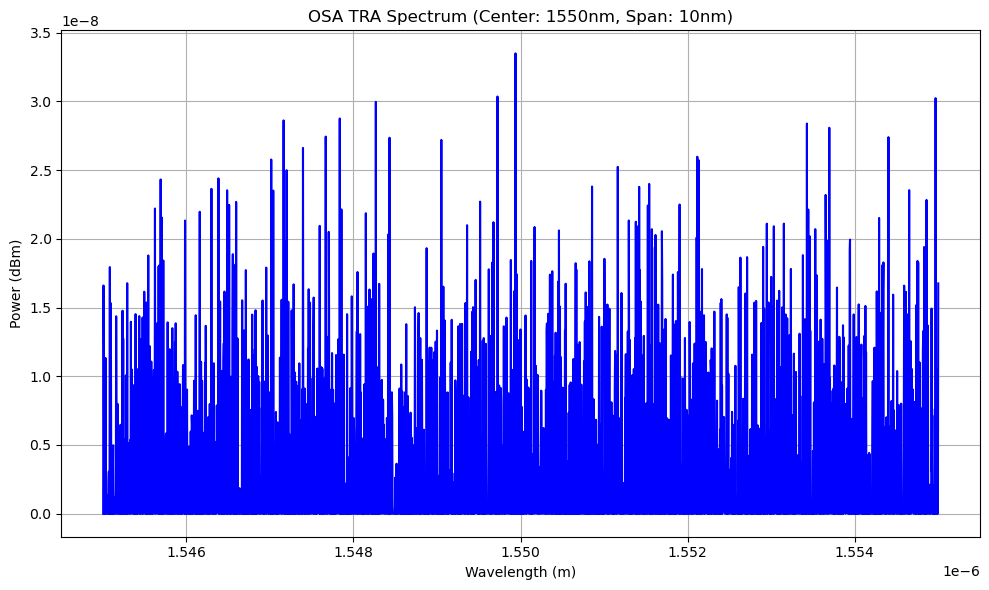

In [12]:
print(f"Downloading Wavelength data (X-axis) from {TRACE_ID}...")
x_data_str = query_osa(f':TRACe:X? {TRACE_ID}')

print(f"Downloading Power Level data (Y-axis) from {TRACE_ID}...")
y_data_str = query_osa(f':TRACe:Y? {TRACE_ID}')

# Parse the data into Python lists
wavelengths = [float(val) for val in x_data_str.split(',')][1:]
power_levels = [float(val) for val in y_data_str.split(',')][1:]

print(f"Successfully downloaded {len(wavelengths)} data points!")

# Generate the Plot
plt.figure(figsize=(10, 6))
plt.plot(wavelengths, power_levels, color='blue', linewidth=1.5)
plt.title(f'OSA {TRACE_ID} Spectrum (Center: {CENTER_WL}, Span: {SPAN})')
plt.xlabel('Wavelength (m)')

# Automatically adjust the Y-axis label
if Y_UNIT.upper().startswith('LOG'):
    plt.ylabel('Power (dBm)')
else:
    plt.ylabel('Power (Watts)')

plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
print("Closing connection.")
s.close()